In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

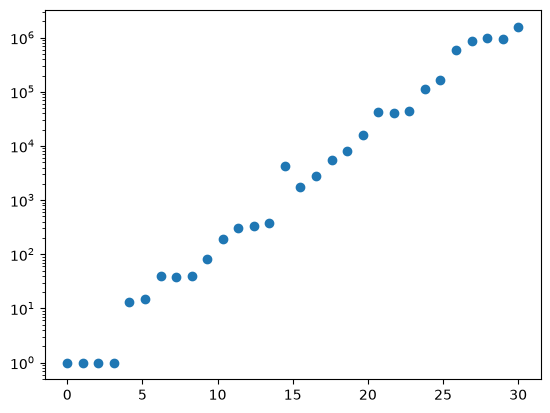

In [97]:
def colonia_sim(N0 = 1, tau = 1, T0=0, T1=1, steps = 10000, measurements=None, sigma_log=0.05, seed=42):
    np.random.seed(seed)


    times = np.linspace(T0,T1,steps)
    sizes = np.zeros(steps)
    sizes[0] = N0
    N = N0

    p = tau*(T1-T0)/steps
    for i in range(1,steps):
        N = N + np.random.binomial(N,p)
        sizes[i] = N


    if measurements is None:
        measurements = np.linspace(T0, T1, 10)
    else:
        measurements = np.sort(np.array(measurements))

    measured_sizes = np.interp(measurements, times, sizes)
    measured_sizes = np.round(measured_sizes).astype(int)


    noise = np.random.lognormal(0, sigma_log, size=len(measurements))
    measured_sizes = np.maximum(1, np.round(measured_sizes * noise)).astype(int)


    return measurements, measured_sizes

times, sizes = colonia_sim(tau=0.5,T1=30,measurements = np.linspace(0,30,30),sigma_log=0.4)

plt.scatter(times,sizes)
plt.yscale("log")

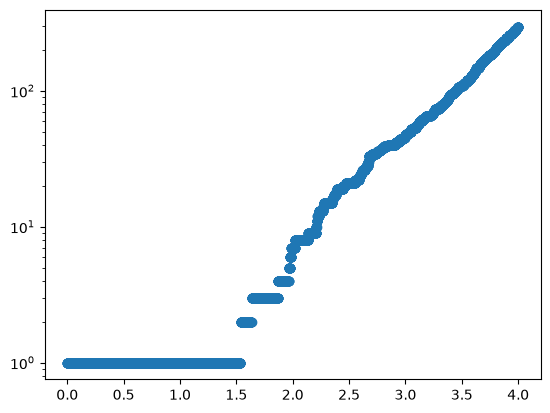

In [56]:
pasos = [1e3]

for p in pasos:
    times, sizes = colonia_sim(tau=2, measurements=10000)

    plt.scatter(times,sizes)
plt.yscale('log')

In [49]:
np.log(2)

np.float64(0.6931471805599453)

In [20]:
?np.log2

Signature:      
np.log2(
    x,
    /,
    out=None,
    *,
    where=True,
    casting='same_kind',
    order='K',
    dtype=None,
    subok=True,
    signature=None,
)
Call signature:  np.log2(*args, **kwargs)
Type:            ufunc
String form:     <ufunc 'log2'>
File:            e:\austral\inferencia-bayesiana\venv\lib\site-packages\numpy\__init__.py
Docstring:      
log2(x, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

Base-2 logarithm of `x`.

Parameters
----------
x : array_like
    Input values.
out : ndarray, None, or tuple of ndarray and None, optional
    A location into which the result is stored. If provided, it must have
    a shape that the inputs broadcast to. If not provided or None,
    a freshly-allocated array is returned. A tuple (possible only as a
    keyword argument) must have length equal to the number of outputs.
where : array_like, optional
    This condition is broadcast over the input. At locations where